In [108]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from tqdm import tqdm
from ipywidgets import interact, IntSlider
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit
import os


import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import os
import pickle
import json
#### PLOT THE DATA #######
# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/configure_laser/'


In [109]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 


with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
particle_ref=line.particle_ref

line.build_tracker()
#line.freeze_longitudinal()
# line.optimize_for_tracking()

twiss=line.twiss()

clight=constants.speed_of_light
circumference = line.get_length()


#%%
###################
# Linear Transfer #
###################

qx=twiss['qx']
qy=twiss['qy']
dqx=twiss['dqx']
dqy=twiss['dqy']
circumference=twiss['s'][-1]
# beta_x=twiss['betx'][-1]
# beta_y=twiss['bety'][-1]

qs=twiss['qs']
bets=twiss['bets0']
voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=twiss['momentum_compaction_factor']
slip_factor=['slip_factor']

# qs=0.0131
# bets=0.063/2e-4

#at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522


Dy  =  0.0 # m
Dpy =  0.0

#index of gamma factory along SPS line: 16675

arc = xt.LineSegmentMap(
        qx=qx, qy=qy,
        dqx=0, dqy=0,
        length=circumference,
        alfx=alpha_x,
        alfy=alpha_y,
        betx=beta_x,
        bety=beta_y,
        
        dx=Dx,
        dpx=Dpx,
        dy=Dy,
        dpy=Dpy,
        # qs=qs,
        # bets=bets,
        voltage_rf=voltage_rf,
        lag_rf=lag_rf,
        frequency_rf=frequency,
        momentum_compaction_factor=momentum_compaction_factor,
        longitudinal_mode = 'nonlinear',

        )


Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [110]:
from ion_properties import lead,calcium,xenon,xenon2nd

In [ ]:
ions_list=lead,xenon,calcium

for ion in [lead]:# Ion properties:
        q0 = ion.q0
        mass0 = ion.mass0
        # print('mass0',mass0*1e-9)

        # gamma = 96.08563421444993
        # gamma =96.08823512129918
        gamma = ion.gamma_rel
        #gamma = 205.62
        
        beta= np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref

        nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z= ion.bunch_length

        # emittance=nemitt/(beta*gamma)

        num_particles=int(5e4)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()

        particles = xp.generate_matched_gaussian_bunch(
                num_particles=num_particles,
                total_intensity_particles=bunch_intensity,
                nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
                particle_ref=particle_ref,
                line=line_arc,
                )
        particles._init_random_number_generator()        
        particles0=particles.copy()

        # sigma_dp=2e-4  
        sigma_dp=np.std(particles.delta)
        print('sigma_dp',sigma_dp*1e4)
        sigma_dp=2e-4 
        ##################
        # Laser Cooler #
        ##################

        #laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        theta_l=ion.theta_l
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        # Ion excitation energy:
        ion_excited_lifetime=ion.excited_lifetime
        hw0 = ion.hw0 # eV
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        #lambda_l = ion.lambda_l
        hw = hw0/(2*gamma) # eV (ħω)

        lambda_l_alexey = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l))/2 # m
        lambda_l = gamma * (1 + beta * np.cos(theta_l)) * lambda_0

        #lambda_l = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l)) # m

        # Shift laser wavelength for fast longitudinal cooling:
        #lambda_l = lambda_l*(1+1*sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        #laser_energy = ion.pulse_energy
        laser_x = 0.5033557046979871*1e-3
        laser_x = 0

        GF_IP = xt.PulsedLaser(
                        laser_x=laser_x,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )
        
        T_per_turn = circumference/(clight*beta)
                        
        # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
        max_time_s = T_per_turn
        int_time_s = T_per_turn
        num_turns = int(max_time_s/T_per_turn)        
        save_interval = int(int_time_s/T_per_turn)


        # create a monitor object, to reduce holded data
        monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
                                
        line = xt.Line(
                elements=[arc,GF_IP,monitor])
        
        # line = xt.Line(
        #         elements=[monitor,arc])

        context = xo.ContextCpu(omp_num_threads=1)
        line.build_tracker(_context=context)

        particles=particles0.copy()
        particles._init_random_number_generator()  

        line.track(particles, num_turns=num_turns,
                turn_by_turn_monitor=False,with_progress=False)

        # extract relevant values
        x = monitor.x[:,0]
        px = monitor.px[:,0]
        y = monitor.y[:,0]
        py = monitor.py[:,0]
        delta = monitor.delta[:,0]
        zeta = monitor.zeta[:,0]
        state = monitor.state[:,0]
        time = monitor.at_turn[:, 0] * T_per_turn

        gamma_x=(1+alpha_x**2)/beta_x
        gamma_y=(1+alpha_y**2)/beta_y

        action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
        action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

        emittance_x_twiss=np.mean(action_x)**beta*gamma/2
        rms_dp_p=np.std(delta)
        
        excited=state==2

        fraction_excitation = sum(excited)/len(excited)*100              


        

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
*** Maximum RMS bunch length 0.2341065571530257m.
... distance to target bunch length: -6.1446e-02
... distance to target bunch length: 1.6464e-01
... distance to target bunch length: 7.5601e-02
... distance to target bunch length: -4.4825e-03
... distance to target bunch length: -2.2826e-05
... distance to target bunch length: -1.0638e-08
... distance to target bunch length: 3.1663e-07
--> Bunch length: 0.06299998936213065
--> Emittance: 0.12256019580565986
sigma_dp 1.9681389360721866
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [112]:
sigma_z

0.063

In [113]:
# turn=1

# plt.figure()
# plt.title(f'Fraction excited: {round(fraction_excitation, 1)}%')

# #plt.axvline(laser_x,color='red')
# # plt.axvline(laser_x+laser_waist_radius,color='red')
# # plt.axvline(laser_x-laser_waist_radius,color='red')

# plt.scatter(x,delta)
# plt.scatter(x[excited],delta[excited])
# plt.xlabel('x [m]')
# plt.ylabel('dp/p ')
# plt.tight_layout()
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# x_min, x_max = plt.xlim()
# y_min, y_max = plt.ylim()
# #plt.savefig('First_turn.eps', format='eps', dpi=300)
# plt.show()



In [114]:
fig_width

5.905511811023622

In [115]:
fig_height

3.6496062992125986

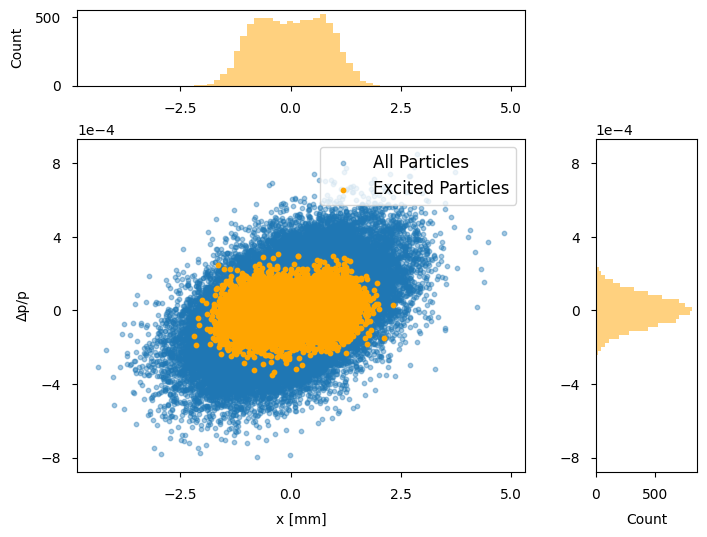

16.156000000000002


In [116]:
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator


# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x * 1e3, delta, s=10, alpha=0.4, label='All Particles')
ax_main.scatter(x[excited] * 1e3, delta[excited], s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('x [mm]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 30
ax_top.hist(x[excited] * 1e3, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 30
ax_right.hist(delta[excited], bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='orange')
ax_right.set_xlabel('Count', labelpad=8)

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
image_name = 'configure_lambda_0.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'configure_lambda_0.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()
print(fraction_excitation)

In [117]:
np.std(zeta)

np.float64(0.06312998126648456)

In [118]:
ions_list=lead,xenon,calcium

for ion in [lead]:# Ion properties:
        q0 = ion.q0
        mass0 = ion.mass0
        # print('mass0',mass0*1e-9)

        # gamma = 96.08563421444993
        # gamma =96.08823512129918
        gamma = ion.gamma_rel
        #gamma = 205.62
        
        beta= np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref

        nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z= ion.bunch_length

        # emittance=nemitt/(beta*gamma)

        num_particles=int(5e4)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()

        particles = xp.generate_matched_gaussian_bunch(
                num_particles=num_particles,
                total_intensity_particles=bunch_intensity,
                nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
                particle_ref=particle_ref,
                line=line_arc,
                #ngine="single-rf-harmonic",        
                )
        particles._init_random_number_generator()        
        particles0=particles.copy()

        # sigma_dp=2e-4  
        sigma_dp=np.std(particles.delta)
        print('sigma_dp',sigma_dp*1e4)
        sigma_dp=2e-4 
        ##################
        # Laser Cooler #
        ##################

        #laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        # Ion excitation energy:
        ion_excited_lifetime=ion.excited_lifetime
        hw0 = ion.hw0 # eV
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        #lambda_l = ion.lambda_l
        hw = hw0/(2*gamma) # eV (ħω)

        #lambda_l_alexey = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l))/2 # m
        lambda_l = gamma * (1 + beta * np.cos(theta_l)) * lambda_0

        #lambda_l = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l)) # m

        # Shift laser wavelength for fast longitudinal cooling:
        lambda_l = lambda_l*(1+1*sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        
        laser_x = 0.5033557046979871*1e-3
        laser_x= 0

        GF_IP = xt.PulsedLaser(
                        laser_x=laser_x,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )
        
        T_per_turn = circumference/(clight*beta)
                        
        # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
        max_time_s = T_per_turn
        int_time_s = T_per_turn
        num_turns = int(max_time_s/T_per_turn)        
        save_interval = int(int_time_s/T_per_turn)


        # create a monitor object, to reduce holded data
        monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
                                
        line = xt.Line(
                elements=[arc,GF_IP,monitor])
        
        # line = xt.Line(
        #         elements=[monitor,arc])

        context = xo.ContextCpu(omp_num_threads=1)
        line.build_tracker(_context=context)

        particles=particles0.copy()
        particles._init_random_number_generator()  

        line.track(particles, num_turns=num_turns,
                turn_by_turn_monitor=False,with_progress=False)

        # extract relevant values
        x = monitor.x[:,0]
        px = monitor.px[:,0]
        y = monitor.y[:,0]
        py = monitor.py[:,0]
        delta = monitor.delta[:,0]
        zeta = monitor.zeta[:,0]
        state = monitor.state[:,0]
        time = monitor.at_turn[:, 0] * T_per_turn

        gamma_x=(1+alpha_x**2)/beta_x
        gamma_y=(1+alpha_y**2)/beta_y

        action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
        action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

        emittance_x_twiss=np.mean(action_x)**beta*gamma/2
        rms_dp_p=np.std(delta)
        
        excited=state==2

        fraction_excitation = sum(excited)/len(excited)*100              


        

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
*** Maximum RMS bunch length 0.2341065571530257m.
... distance to target bunch length: -6.1446e-02
... distance to target bunch length: 1.6464e-01
... distance to target bunch length: 7.5601e-02
... distance to target bunch length: -4.4825e-03
... distance to target bunch length: -2.2826e-05
... distance to target bunch length: -1.0638e-08
... distance to target bunch length: 3.1663e-07
--> Bunch length: 0.06299998936213065
--> Emittance: 0.12256019580565986
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 1.9618787009229817
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


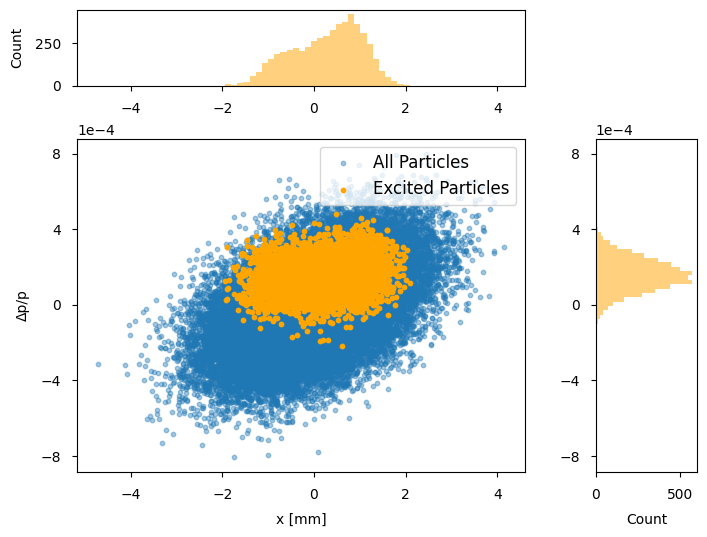

10.671999999999999


In [119]:
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator


# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x * 1e3, delta, s=10, alpha=0.4, label='All Particles')
ax_main.scatter(x[excited] * 1e3, delta[excited], s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('x [mm]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 30
ax_top.hist(x[excited] * 1e3, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 30
ax_right.hist(delta[excited], bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='orange')
ax_right.set_xlabel('Count', labelpad=8)

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
image_name = 'configure_lambda_l.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'configure_lambda_l.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()
print(fraction_excitation)

pulse duration

In [120]:
ions_list=lead,xenon,calcium

for ion in [lead]:# Ion properties:
        q0 = ion.q0
        mass0 = ion.mass0
        # print('mass0',mass0*1e-9)

        # gamma = 96.08563421444993
        # gamma =96.08823512129918
        gamma = ion.gamma_rel
        #gamma = 205.62
        
        beta= np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref

        nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z= ion.bunch_length

        # emittance=nemitt/(beta*gamma)

        num_particles=int(5e4)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()

        particles = xp.generate_matched_gaussian_bunch(
                num_particles=num_particles,
                total_intensity_particles=bunch_intensity,
                nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
                particle_ref=particle_ref,
                line=line_arc,
                #ngine="single-rf-harmonic",        
                )
        particles._init_random_number_generator()        
        particles0=particles.copy()

        # sigma_dp=2e-4  
        sigma_dp=np.std(particles.delta)
        print('sigma_dp',sigma_dp*1e4)
        sigma_dp=2e-4 
        ##################
        # Laser Cooler #
        ##################

        #laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        # Ion excitation energy:
        ion_excited_lifetime=ion.excited_lifetime
        hw0 = ion.hw0 # eV
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        #lambda_l = ion.lambda_l
        hw = hw0/(2*gamma) # eV (ħω)

        #lambda_l_alexey = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l))/2 # m
        lambda_l = gamma * (1 + beta * np.cos(theta_l)) * lambda_0

        #lambda_l = (2*np.pi*hc/hw)*(1 + beta*np.cos(theta_l)) # m

        # Shift laser wavelength for fast longitudinal cooling:
        lambda_l = lambda_l*(1+1*sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling
        
        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        
        laser_x = 0.5033557046979871*1e-3
        laser_x= 0

        GF_IP = xt.PulsedLaser(
                        laser_x=laser_x,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )
        
        T_per_turn = circumference/(clight*beta)
                        
        # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
        max_time_s = T_per_turn
        int_time_s = T_per_turn
        num_turns = int(max_time_s/T_per_turn)        
        save_interval = int(int_time_s/T_per_turn)


        # create a monitor object, to reduce holded data
        monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
                                
        line = xt.Line(
                elements=[arc,GF_IP,monitor])
        
        # line = xt.Line(
        #         elements=[monitor,arc])

        context = xo.ContextCpu(omp_num_threads=1)
        line.build_tracker(_context=context)

        particles=particles0.copy()
        particles._init_random_number_generator()  

        line.track(particles, num_turns=num_turns,
                turn_by_turn_monitor=False,with_progress=False)

        # extract relevant values
        x = monitor.x[:,0]
        px = monitor.px[:,0]
        y = monitor.y[:,0]
        py = monitor.py[:,0]
        delta = monitor.delta[:,0]
        zeta = monitor.zeta[:,0]
        state = monitor.state[:,0]
        time = monitor.at_turn[:, 0] * T_per_turn

        gamma_x=(1+alpha_x**2)/beta_x
        gamma_y=(1+alpha_y**2)/beta_y

        action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
        action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

        emittance_x_twiss=np.mean(action_x)**beta*gamma/2
        rms_dp_p=np.std(delta)
        
        excited=state==2

        fraction_excitation = sum(excited)/len(excited)*100              


        

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
*** Maximum RMS bunch length 0.2341065571530257m.
... distance to target bunch length: -6.1446e-02
... distance to target bunch length: 1.6464e-01
... distance to target bunch length: 7.5601e-02
... distance to target bunch length: -4.4825e-03
... distance to target bunch length: -2.2826e-05
... distance to target bunch length: -1.0638e-08
... distance to target bunch length: 3.1663e-07
--> Bunch length: 0.06299998936213065
--> Emittance: 0.12256019580565986
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 1.9747076213319918
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


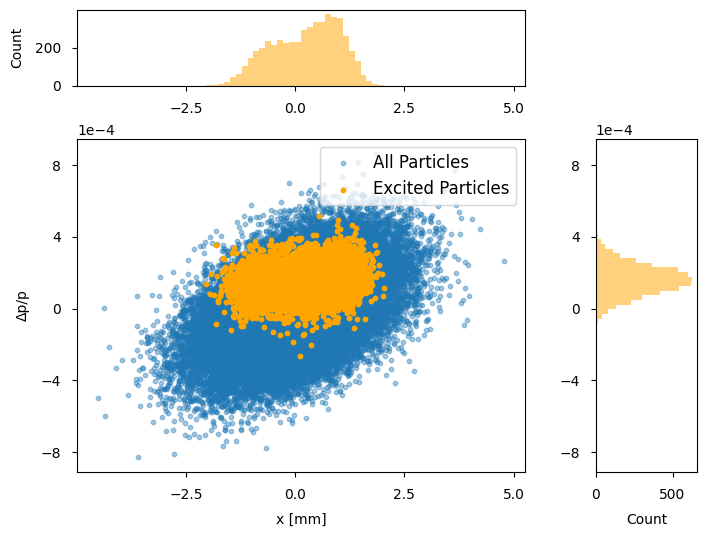

10.367999999999999


In [121]:
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator


# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x * 1e3, delta, s=10, alpha=0.4, label='All Particles')
ax_main.scatter(x[excited] * 1e3, delta[excited], s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('x [mm]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 30
ax_top.hist(x[excited] * 1e3, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 30
ax_right.hist(delta[excited], bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='orange')
ax_right.set_xlabel('Count', labelpad=8)

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
# image_name = 'configure_pulse_duration.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')

# pickle_filename = 'configure_pulse_duration.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)

plt.show()
print(fraction_excitation)

In [122]:
sigma_t

np.float64(2.7391032530476336e-12)

Rabi

In [123]:
hw0 = ion.hw0 # eV

In [132]:
hbar = 1.054571817e-34
c=constants.c
QELEM=constants.e

w0=laser_waist_radius

I0 = np.sqrt(2/np.pi)*(laser_energy/sigma_t)/(np.pi*w0*w0)
#I = 4.0*gamma*gamma * I0*(w0/w)**2*np.exp(-2.0*r2/(w*w))

OmegaRabi = (hbar * c / (hw0*QELEM)) * np.sqrt((I0 * 2 * np.pi) / ((hw0*QELEM) * ion_excited_lifetime))

print(f"OmegaRabi = {OmegaRabi:.2e} rad/s")


OmegaRabi = 6.67e+11 rad/s


cw one

In [131]:
OmegaTransition = hw0*QELEM/hbar


OmegaRabi2 = c * np.sqrt(2 * np.pi) * np.sqrt(I0) / np.sqrt(hbar * ion_excited_lifetime * OmegaTransition**3)

print(f"OmegaRabi2 = {OmegaRabi2:.2e} rad/s")

print(f"Peak OmegaRabi2 scaled = {OmegaRabi2/np.sqrt(6):.3e} rad/s")

OmegaRabi2 = 6.67e+11 rad/s
Peak OmegaRabi2 scaled = 2.722e+11 rad/s


simon

In [126]:
import numpy as np
from scipy import constants

# Physical constants
c = constants.c                  # Speed of light (m/s)
hbar = constants.hbar           # Reduced Planck constant (J·s)
pi = np.pi


Gamma = 1/ion_excited_lifetime


# Compute peak Rabi frequency
OmegaR = (2 * c * np.sqrt(I0) * np.sqrt(3 * pi) * np.sqrt(Gamma)) / (OmegaTransition**(3/2) * np.sqrt(hbar))

print(f"Peak OmegaRabi = {OmegaR:.3e} rad/s")


print(f"Peak OmegaRabi scaled = {OmegaR/np.sqrt(6):.3e} rad/s")


Peak OmegaRabi = 1.633e+12 rad/s
Peak OmegaRabi scaled = 6.668e+11 rad/s


In [129]:
import numpy as np

# Constants
hbar = 1.054571817e-34       # Planck constant over 2π [J·s]
c = 299792458                # Speed of light [m/s]



# Compute Ω_R,peak
numerator = 2 * c * I0 * 3 * np.pi * Gamma
denominator = (OmegaTransition ** 1.5) * hbar
omega_R_peak = numerator / denominator

print("Ω_R,peak =", omega_R_peak, "rad/s")


Ω_R,peak = 9.240851889780425e+41 rad/s
